## Importación de librerías

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.metrics import f1_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, recall_score, precision_score

%matplotlib inline
sns.set_theme()

## Carga del dataset

In [2]:
# 1. Cargar los datasets enriquecidos pre-procesados
# Ajusta la ruta si tu carpeta de salida se llama de otra forma (ej. 'generated' o 'procesado')
df_train = pd.read_csv('./../../../dataset/oulad/generated/dataset_train_2013_enriquecido.csv')
df_test = pd.read_csv('./../../../dataset/oulad/generated/dataset_test_2014_enriquecido.csv')

# ====================================================================
# UNDERSAMPLING AL 50% EN EL CONJUNTO DE ENTRENAMIENTO (2013)
# ====================================================================
# Separamos las clases del año 2013
df_train_exito = df_train[df_train['target_burnout'] == 0]
df_train_riesgo = df_train[df_train['target_burnout'] == 1]

# Reducimos la clase de éxito a la mitad (50%) aleatoriamente con semilla fija
df_train_exito_reducido = df_train_exito.sample(frac=0.5, random_state=42)

# Volvemos a unir y mezclamos (shuffle) para que el algoritmo no lea en orden
df_train = pd.concat([df_train_exito_reducido, df_train_riesgo]).sample(frac=1, random_state=42)
# ====================================================================

# 2. Separar características (X) y variable objetivo (y)
# (Las columnas sensibles y metadatos ya fueron eliminadas en el script generador)
X_train = df_train.drop(columns=['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

# 3. Comprobación de la distribución tras el balanceo
print("--- DISTRIBUCIÓN TRAS EL BALANCEO (DATASET ENRIQUECIDO) ---")
print(f"Train 2013 - Total: {len(X_train)} | Riesgo (1): {y_train.sum()} | Éxito (0): {len(y_train) - y_train.sum()}")
print(f"Test 2014  - Total: {len(X_test)} | Riesgo (1): {y_test.sum()} | Éxito (0): {len(y_test) - y_test.sum()}")
print(f"\nNúmero de características (columnas) para el modelo: {X_train.shape[1]}")

--- DISTRIBUCIÓN TRAS EL BALANCEO (DATASET ENRIQUECIDO) ---
Train 2013 - Total: 7245 | Riesgo (1): 3348 | Éxito (0): 3897
Test 2014  - Total: 10801 | Riesgo (1): 3693 | Éxito (0): 7108

Número de características (columnas) para el modelo: 29


## Construcción y Entrenamiento del Pipeline

In [3]:
# 1. Definición de columnas actualizadas al dataset enriquecido
cat_cols = ['highest_education']

num_cols = [
    'num_of_prev_attempts', 'studied_credits',
    'total_clicks_90d', 'media_clicks_semanales', 'total_dias_activos',
    'semanas_con_actividad', 'semanas_actividad_plena', 'max_clicks_1_dia',
    'semanas_sin_clicks', 'dias_sin_clicks_90d',
    'entregas_realizadas_90d', 'nota_media_90d', 'retraso_medio_dias', 'total_entregas_tardias',
    'clicks_semana_0', 'clicks_semana_1', 'clicks_semana_2', 'clicks_semana_3',
    'clicks_semana_4', 'clicks_semana_5', 'clicks_semana_6', 'clicks_semana_7',
    'clicks_semana_8', 'clicks_semana_9', 'clicks_semana_10', 'clicks_semana_11',
    'clicks_semana_12'
]

# 2. Preprocesador (Escalado vital para redes neuronales)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 3. Pipeline Base MLP (Red Neuronal)
mlp_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(100, 50), # 100 neuronas en la capa 1, 50 en la capa 2
        activation='relu',            # Función de activación no lineal estándar
        solver='adam',                # Optimizador de descenso de gradiente
        alpha=0.0001,                 # Penalización L2 (Regularización) base
        max_iter=1000,                # Límite de épocas
        early_stopping=True,          # Detiene el entrenamiento si deja de mejorar (evita sobreajuste)
        random_state=42
    ))
])

# 4. Entrenar modelo
print("Entrenando Perceptrón Multicapa...")
mlp_pipeline.fit(X_train, y_train)

# 5. Generar predicciones con umbral estándar (0.50)
y_pred = mlp_pipeline.predict(X_test)

print("¡Entrenamiento de MLP finalizado con éxito!")

Entrenando Perceptrón Multicapa...
¡Entrenamiento de MLP finalizado con éxito!


## Evaluación y Gráficas de Rendimiento

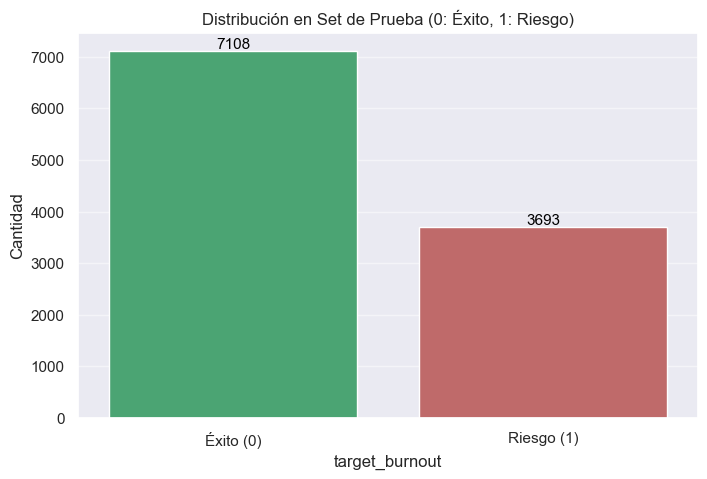

--- REPORTE DE CLASIFICACIÓN DETALLADO (MLP) ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.85      7108
           1       0.69      0.77      0.73      3693

    accuracy                           0.80     10801
   macro avg       0.78      0.80      0.79     10801
weighted avg       0.81      0.80      0.81     10801



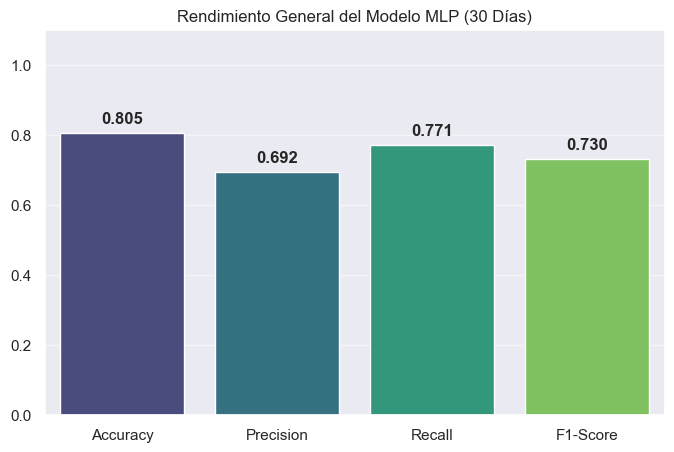

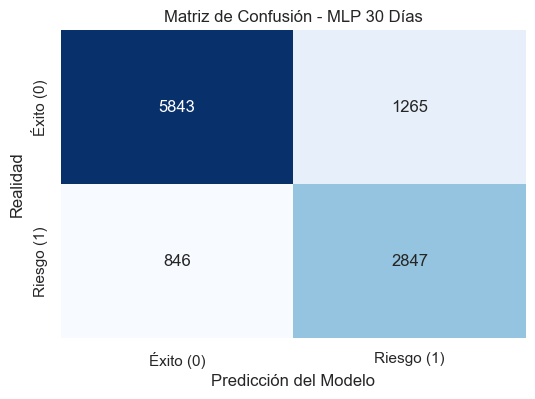

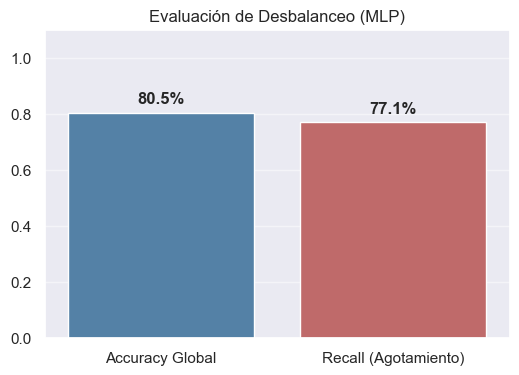

In [4]:
fig1 = plt.figure(figsize=(8, 5))

ax1 = sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False)
plt.title('Distribución en Set de Prueba (0: Éxito, 1: Riesgo)')
plt.xticks(ticks=[0, 1], labels=['Éxito (0)', 'Riesgo (1)'])
plt.ylabel('Cantidad')

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')
plt.show()


acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("--- REPORTE DE CLASIFICACIÓN DETALLADO (MLP) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# ==========================================
# GRÁFICO 2: Visualización de Métricas Habituales
# ==========================================
fig2 = plt.figure(figsize=(8, 5))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [acc, prec, rec, f1]
ax2 = sns.barplot(x=metrics_names, y=metrics_values, hue=metrics_names, palette='viridis', legend=False)
plt.title('Rendimiento General del Modelo MLP (30 Días)')
plt.ylim(0, 1.1)

for i, v in enumerate(metrics_values):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')
plt.show()

# ==========================================
# GRÁFICO 3: Matriz de Confusión
# ==========================================
cm = confusion_matrix(y_test, y_pred)

fig3 = plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
plt.title('Matriz de Confusión - MLP 30 Días')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad')
plt.show()

# ==========================================
# GRÁFICO 4: Accuracy Global vs Recall Minoritario
# ==========================================
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

fig4 = plt.figure(figsize=(6, 4))

metric_names_comp = ['Accuracy Global', 'Recall (Agotamiento)']
metric_values_comp = [acc, burnout_recall]
ax4 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, palette=['#4682B4', '#CD5C5C'], legend=False)
plt.title('Evaluación de Desbalanceo (MLP)')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax4.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')
plt.show()

## Grid search (Busqueda de hiperparametros)

In [ ]:
# ==========================================
# 1. CONFIGURACIÓN DEL ESPACIO DE BÚSQUEDA (MLP PROFUNDO)
# ==========================================
param_grid_mlp_profundo = {
    # Arquitecturas de 3 a 5 capas ocultas, con 50 a 200 neuronas
    'classifier__hidden_layer_sizes': [
        (200, 150, 100, 50),            # 4 capas
        (200, 200, 150, 100, 50)        # 5 capas de alta densidad
    ],

    # Todas las funciones de activación soportadas
    'classifier__activation': ['relu', 'tanh', 'logistic', 'identity'],

    # Iteraciones para evaluar distintos niveles de ajuste/error
    'classifier__max_iter': [200, 500, 5000],

    # Alternar entre detenerse si no mejora o forzar el entrenamiento hasta el límite
    'classifier__early_stopping': [True, False],

    # Tasa de aprendizaje
    'classifier__learning_rate_init': [0.001, 0.01]
}

print("Iniciando Grid Search para Perceptrón Multicapa (Alta Complejidad)...")
print("Este proceso evaluará 192 combinaciones distintas (576 entrenamientos con CV=3).")

# ==========================================
# 2. EJECUCIÓN DE LA BÚSQUEDA
# ==========================================
grid_search_mlp = GridSearchCV(
    estimator=mlp_pipeline, # Se asume que mlp_pipeline está definido en la celda anterior
    param_grid=param_grid_mlp_profundo,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2 # Verbose 2 para ver el progreso de cada iteración por pantalla
)

grid_search_mlp.fit(X_train, y_train)

# ==========================================
# 3. RESULTADOS DE LA OPTIMIZACIÓN
# ==========================================
print("\n" + "=" * 50)
print("¡BÚSQUEDA MLP FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search_mlp.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("=" * 50)

# ==========================================
# 4. PRUEBA CON EL MODELO GANADOR Y BARRIDO DE UMBRALES
# ==========================================
mejor_modelo_mlp = grid_search_mlp.best_estimator_

# Extraemos las probabilidades de la clase 1 (Riesgo)
y_probs_mlp = mejor_modelo_mlp.predict_proba(X_test)[:, 1]

# Reporte con el umbral base (0.50)
umbral_base = 0.50
y_pred_mlp = (y_probs_mlp >= umbral_base).astype(int)

print(f"\n--- REPORTE DEL MEJOR MODELO MLP (Umbral: {umbral_base}) ---")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

print("\n" + "=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO MLP GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)

# Barrido diferencial para encontrar el punto óptimo
umbrales_prueba = np.arange(0.30, 0.85, 0.05)

for u in umbrales_prueba:
    y_pred_temp = (y_probs_mlp >= u).astype(int)

    acc = accuracy_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp, zero_division=0)
    prec = precision_score(y_test, y_pred_temp, zero_division=0)

    print(f"{u:.2f}     | {acc * 100:>5.1f}%             | {rec * 100:>5.1f}%             | {prec * 100:>5.1f}%")

Iniciando Grid Search para Perceptrón Multicapa (Alta Complejidad)...
Este proceso evaluará 192 combinaciones distintas (576 entrenamientos con CV=3).
Fitting 3 folds for each of 96 candidates, totalling 288 fits
